Goal: calculate sigma from the matter power spectrum. Use sigma to calculate the HMF

In [2]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt
import scipy
from astropy import units as u
import zeus21 as zeus21
from scipy.interpolate import RegularGridInterpolator

plt.style.use('/Users/eb35267/Desktop/research/mpl_style/estyle.mplstyle')
plt.style.use('/Users/eb35267/Desktop/research/mpl_style/notebook_style.mplstyle')

Following tutorial from https://cluster-toolkit.readthedocs.io/en/latest/source/using_class.html \
I've changed the input parameters; follow the link to the the originals from the tutorial. \
In Class, everything is given in units of Mpc, unless otherwise specified (found this in background.c)

# Initiating Class

In [3]:
# # Start by specifying the cosmology
# # This cosmology comes from Bullock & Boylan-Kolchin, 2017 which in turn comes from Planck Collaboration, 2016
Omega_b = 0.04927
Omega_m = 0.3156
Omega_cdm = Omega_m - Omega_b
Omega_Lambda = 0.6844
sigma8 = 0.831
h = 0.6727 #H0/100
n_s = 0.9645
k_max = 1e4 #UNITS: 1/Mpc

params = { 'output': 'mPk',
          'non linear': 'halofit',
          'Omega_b': Omega_b,
          'Omega_cdm': Omega_cdm,
          'h': h,
          'P_k_max_1/Mpc': k_max,

          'z_max_pk': 10. # Default value
}

In [4]:
#Initialize the cosmology and compute everything
cosmo = Class()
cosmo.set(params)
cosmo.compute()

In [5]:
#Specify k and z
k = np.logspace(-4, 1, num=1000)*u.Mpc**-1 #Mpc^-1
z = 0

In [6]:
#Call these for the nonlinear and linear matter power spectra
Pnonlin = np.array([cosmo.pk(ki.value, z) for ki in k])*u.Mpc**-3
Plin = np.array([cosmo.pk_lin(ki.value, z) for ki in k])*u.Mpc**-3

Text(0, 0.5, 'P(k)/$Mpc^3$')

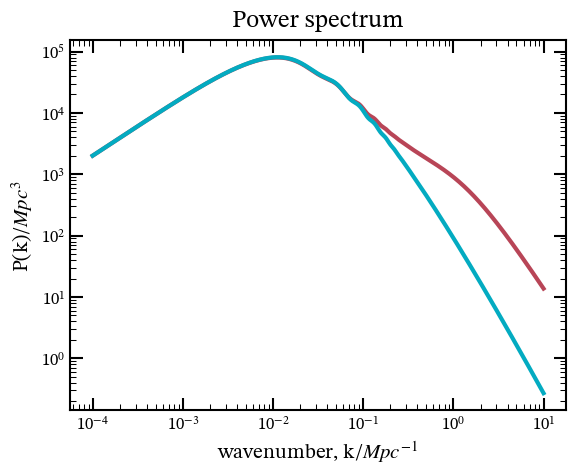

In [7]:
plt.plot(k, Pnonlin)
plt.plot(k, Plin)
plt.yscale('log')
plt.xscale('log')
plt.title('Power spectrum')
plt.xlabel(r'wavenumber, k/$Mpc^{-1}$')
plt.ylabel(r'P(k)/$Mpc^3$')

Text(0, 0.5, '$P(k)*k^3$')

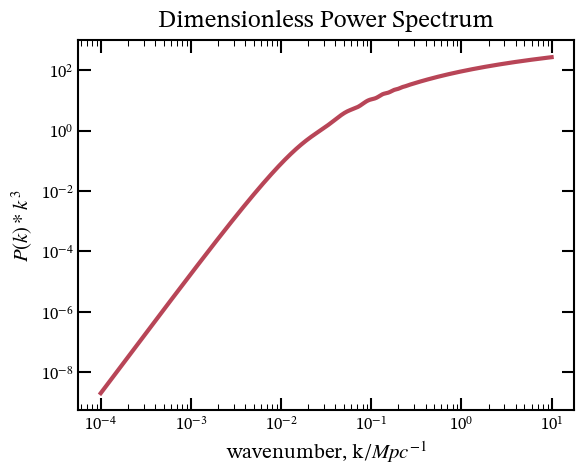

In [8]:
plt.plot(k, Plin*k**3)
plt.yscale('log')
plt.xscale('log')
plt.title('Dimensionless Power Spectrum')
plt.xlabel(r'wavenumber, k/$Mpc^{-1}$')
plt.ylabel(r'$P(k)*k^3$')

# Calculating sigma

$\sigma^2(R) = \frac{1}{2\pi^2} \int_0^{\infty}k^2P(k)W^2(kR)dk = \langle \delta \rangle$ \
Will have to change these bounds to make the integral accomplishable \
$W(kR) = \frac{3(sin(kR)-kRcos(kR))}{(kR)^3}$

In [9]:
def integrand(k, R, z):
    P = cosmo.pk_lin(k, z)
    W = 3*(np.sin(k*R)-(k*R*np.cos(k*R)))/((k*R)**3)
    return (1/(2*np.pi**2))*k**2*P*W**2

In [10]:
def calc_sigma(R, k_range):
    return np.sqrt(np.trapz([integrand(k, R=R, z=z) for k in k_range], k_range, dx = 1e-4))

In [11]:
k_range = np.logspace(-4, 4, 1000)
R_values = np.logspace(-0.2, 2, 1000)
sigma = np.zeros_like(R_values)
for i, R in enumerate(R_values):
    sigma[i] = calc_sigma(R, k_range)

Text(0.5, 0, 'R (Mpc)')

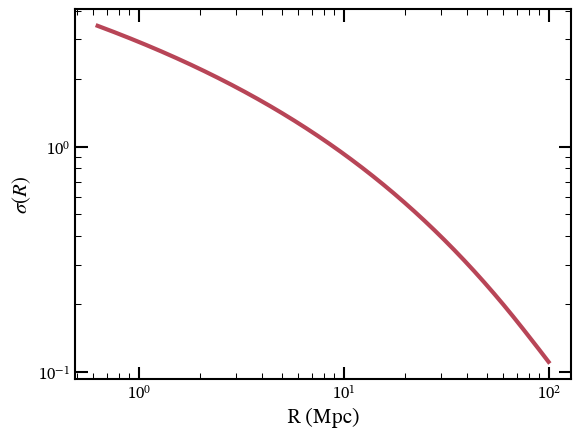

In [12]:
plt.plot(R_values, sigma)
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'$\sigma(R)$')
plt.xlabel('R (Mpc)')

In [13]:
# Compare to Class matter variance
sigma_class = [cosmo.sigma(R, z) for R in R_values]

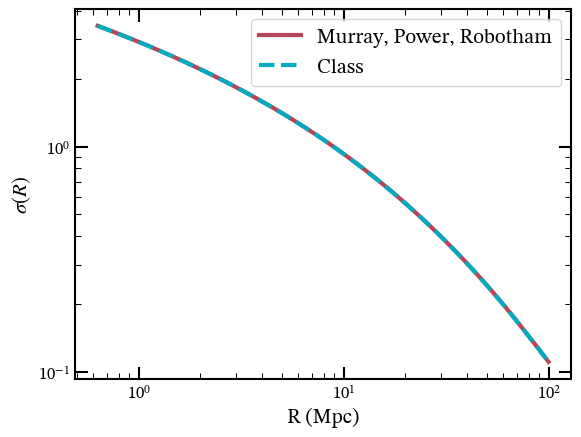

In [14]:
plt.plot(R_values, sigma, label = 'Murray, Power, Robotham')
plt.plot(R_values, sigma_class, linestyle = '--', label = 'Class')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'$\sigma(R)$')
plt.xlabel('R (Mpc)')
plt.legend()

# Calculating the HMF

## Setting up the calculation

Start with the Press-Schechter fitting function, which defines the fraction of mass collapsed: \
$f(\sigma) = \sqrt{\frac{2}{\pi}} \frac{\delta_c}{\sigma} \exp[-\frac{\delta_c^2}{2\sigma^2}]$ \
where $\delta_c = 1.686$ (critical overdensity for spherical collapse)

In [15]:
delta_c = 1.686
f = np.sqrt(2/np.pi)*delta_c/sigma*(np.e**(-(delta_c**2)/(2*sigma**2)))

Text(0.5, 0, 'R (Mpc)')

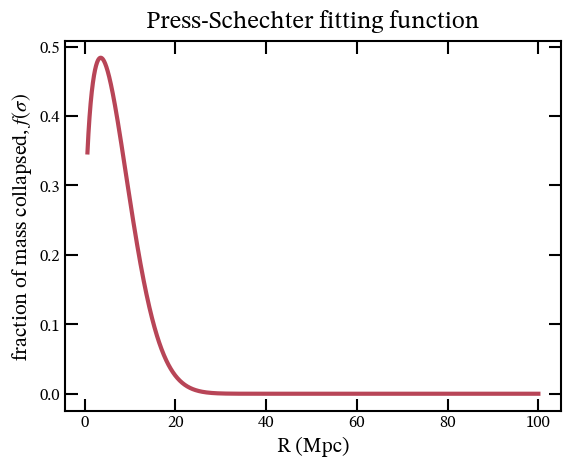

In [16]:
plt.plot(R_values, f)
plt.title('Press-Schechter fitting function')
plt.ylabel(r'fraction of mass collapsed, $f(\sigma)$')
plt.xlabel('R (Mpc)')

Use the equation: \
$\frac{dn}{d\ln M} = M*\frac{\rho_0}{M^2}*f(\sigma)*|\frac{d\ln\sigma}{d\ln M}|$ \
where $\rho_0$ is the cosmology-dependent mean density and: \
$M = \frac{4\pi\rho_{(0,M)}}{3} R^3$ -- use this to turn $\sigma(R)$ into $\sigma(M)$

Use $\rho_{crit, 0} = \frac{3H_0^2}{8\pi G}$ \
and $\rho_0 = \Omega_{tot} * \rho_{crit, 0}$

In [17]:
H0_over_c = cosmo.Hubble(z)/u.Mpc 
c = 3e8*u.m/u.s
H0 = (H0_over_c * c).to(u.s**-1)
G = 6.67430e-11* u.m**3 * u.s**-2 * u.kg**-1

In [18]:
rho_crit_0 = ((3*H0**2)/(8*np.pi*G)).to(u.Msun/u.Mpc**3)

In [19]:
Omega_tot = cosmo.Omega_Lambda() + cosmo.Omega_m() + cosmo.Omega_r() # This should equal 1 in the cosmology I've chosen (aka a flat universe)

In [20]:
rho_0M = (Omega_m * rho_crit_0).value
rho_0 = (Omega_tot*rho_crit_0).value

In [21]:
rho_0M/1e10

3.9691842531777137

In [22]:
def sigma_M(M, rho_0M, k_range):
    print(rho_0M/1e10)
    R = ((3*M)/(4*np.pi*rho_0M))**(1/3)
    return calc_sigma(R, k_range)

In [23]:
def f_PS(M, delta_c, rho_0M, k_range):
    print(rho_0M/1e10)
    sigma = sigma_M(M, rho_0M, k_range)
    return np.sqrt(2/np.pi)*delta_c/sigma*np.exp(-(delta_c**2/(2*sigma**2)))

In [24]:
def sigma_deriv(M_range, rho_0M, k_range):
    print(rho_0M/1e10)
    sigma_M_range = np.array([sigma_M(M_curr, rho_0M, k_range) for M_curr in M_range])
    log_M = np.log(M_range)
    log_sigma = np.log(sigma_M_range)
    return np.abs(np.gradient(log_sigma, log_M))

In [25]:
def calc_hmf(M_range, delta_c, rho_0M, rho_0, k_range, f_type = 'PS'):
    assert f_type in ['PS', 'ST'], 'f_type must be one of PS (Press-Schechter) or ST (Sheth-Tormen)'
    print(rho_0M/1e10)
    hmf = np.zeros_like(M_range)
    derivative = sigma_deriv(M_range, rho_0M, k_range)
    for i, (M, deriv) in enumerate(zip(M_range, derivative)):
        if f_type == 'PS':
            f_M = f_PS(M, delta_c, rho_0M, k_range)
        else:
            f_M = f_ST(M, delta_c, rho_0M, k_range)

        hmf[i] = rho_0/M*f_M*deriv
    return hmf

## Performing the calculation

In [26]:
M_range = np.logspace(7, 15, 100)
hmf_ps = calc_hmf(M_range, delta_c, rho_0M, rho_0, k_range, f_type = 'PS')

3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531

Text(0.5, 0, '$M / M_{\\odot}$')

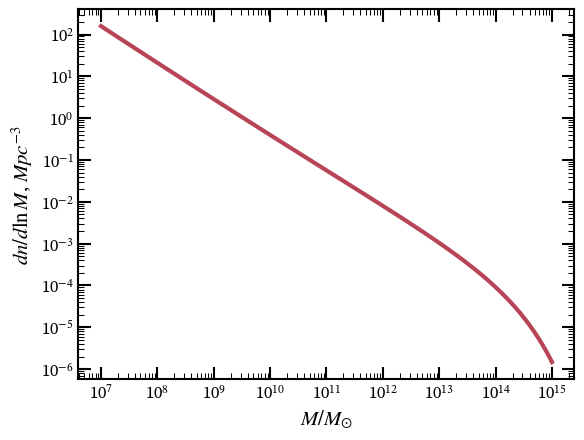

In [27]:
fig, ax = plt.subplots()
ax.plot(M_range, hmf_ps)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel(r'$dn/d\ln M$, $Mpc^{-3}$')
ax.set_xlabel(r'$M / M_{\odot}$')

In [28]:
hmf_ps_bbk_units = np.array(hmf_ps) * np.log(10) # This converts the HMF from dn/dln(M) to dn/dlog_10(M) (Bullock & Boylan-Kolchin review)

Text(0.5, 0, '$M / M_{\\odot}$')

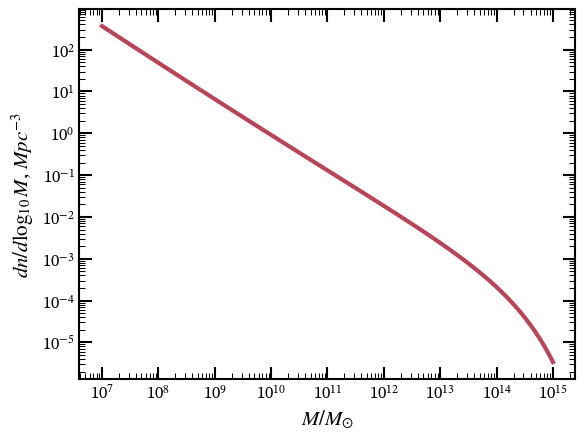

In [29]:
plt.plot(M_range, hmf_ps_bbk_units)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$dn/d\log_{10} M$, $Mpc^{-3}$')
plt.xlabel(r'$M / M_{\odot}$')

Trying again with the Sheth-Tormen formulation of $f(\sigma)$: \
$f(\sigma) = A \sqrt{\frac{2a}{\pi}}[1+(\frac{\sigma^2}{a\delta_c^2})^p] \exp[-\frac{\delta_c^2}{2\sigma^2}]$

In [55]:
def f_ST(M, delta_c, rho_0M, k_range, A = 0.3222, a = 0.707, p = 0.3):
    print(rho_0M)
    sigma = sigma_M(M, rho_0M, k_range)
    return A*np.sqrt(2*a/np.pi)*(1+(sigma**2/(a*delta_c**2)))**p*np.exp(-(a*delta_c**2/(2*sigma**2)))

In [56]:
hmf_st = calc_hmf(M_range, delta_c, rho_0M, rho_0, k_range, f_type = 'ST')

3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531777137
3.9691842531

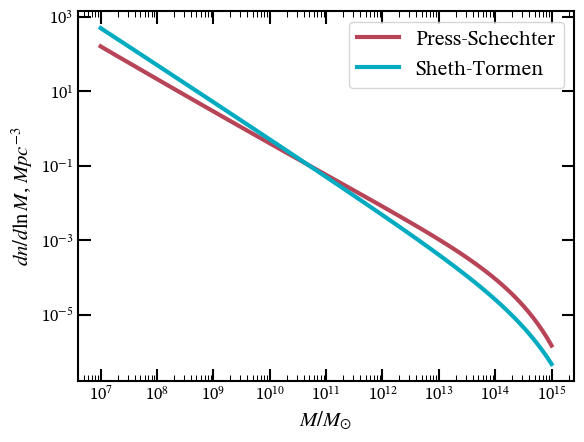

In [57]:
fig, ax = plt.subplots()
ax.plot(M_range, hmf_ps, label = 'Press-Schechter')
ax.plot(M_range, hmf_st, label = 'Sheth-Tormen')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel(r'$dn/d\ln M$, $Mpc^{-3}$')
ax.set_xlabel(r'$M / M_{\odot}$')
plt.legend()

In [33]:
hmf_st_bbk_units = np.array(hmf_st) * np.log(10)

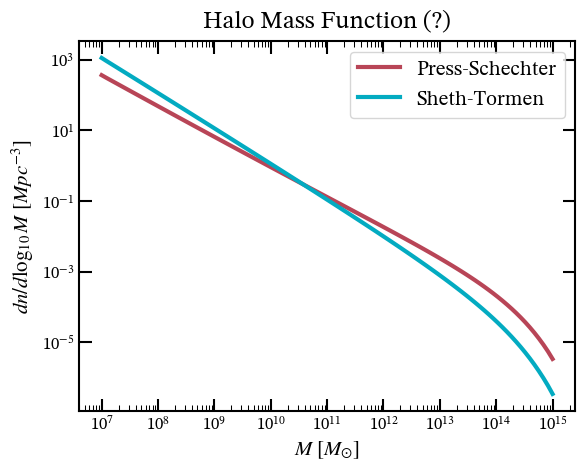

In [34]:
fig, ax = plt.subplots()
ax.plot(M_range, hmf_ps_bbk_units, label = 'Press-Schechter')
ax.plot(M_range, hmf_st_bbk_units, label = 'Sheth-Tormen')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel(r'$dn/d\log_{10} M$ $[Mpc^{-3}]$')
ax.set_xlabel(r'$M$ $[M_{\odot}]$')
ax.set_title('Halo Mass Function (?)')
ax.legend()
# fig.savefig('/Users/eb35267/Desktop/research_code/figures/hmf_attempt.png', bbox_inches = 'tight')

## Comparison to Zeus21

In [35]:
# Zeus21 takes inputs scaled by the hubble parameter
omegab = Omega_b * h**2 
omegam = Omega_m * h**2
omegac = omegam - omegab

In [36]:
CosmoParams_input = zeus21.Cosmo_Parameters_Input(omegab = omegab, omegac = omegac, h_fid = h, ns = n_s, zmin_CLASS = 0, HMF_CHOICE='ST') 
# Can specify the chocie of HMF model here

In [37]:
ClassyCosmo = zeus21.runclass(CosmoParams_input)

In [38]:
CosmoParams = zeus21.Cosmo_Parameters(CosmoParams_input, ClassyCosmo)

In [39]:
HMFintclass = zeus21.HMF_interpolator(CosmoParams,ClassyCosmo)

In [40]:
hmf_zeus = HMFintclass.HMF_int(M_range, z=0)
hmf_zeus_bbk_units = hmf_zeus * M_range * np.log(10)

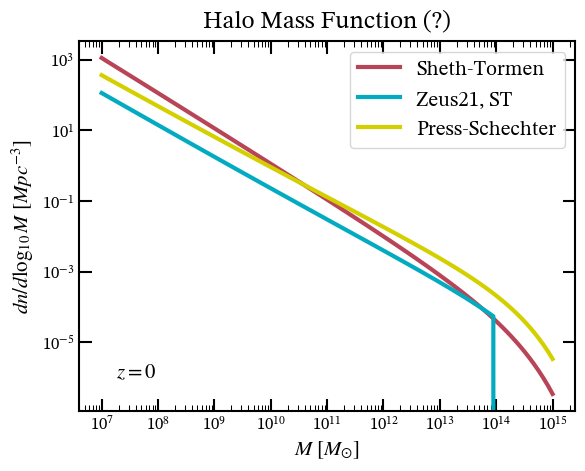

In [41]:
fig, ax = plt.subplots()
ax.plot(M_range, hmf_st_bbk_units, label = 'Sheth-Tormen')
ax.plot(M_range, hmf_zeus_bbk_units, label = 'Zeus21, ST')
ax.plot(M_range, hmf_ps_bbk_units, label = 'Press-Schechter')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel(r'$dn/d\log_{10} M$ $[Mpc^{-3}]$')
ax.set_xlabel(r'$M$ $[M_{\odot}]$')
ax.set_title('Halo Mass Function (?)')
plt.text(0.075, 0.075, r'$z=0$', transform=plt.gca().transAxes, verticalalignment='bottom', horizontalalignment='left')
ax.legend()
#fig.savefig('/Users/eb35267/Desktop/research_code/figures/hmf_attempt_with_zeus.png', bbox_inches = 'tight')

In [42]:
zeus_sigmam = HMFintclass.sigma_int(M_range, z=0)
my_sigmam = [sigma_M(M, rho_0, k_range) for M in M_range]

12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446063732
12.576629446

Text(0, 0.5, '$\\frac{|\\sigma_{M, MPR} - \\sigma_{M, Zeus}|}{\\sigma_{M, Zeus}}$')

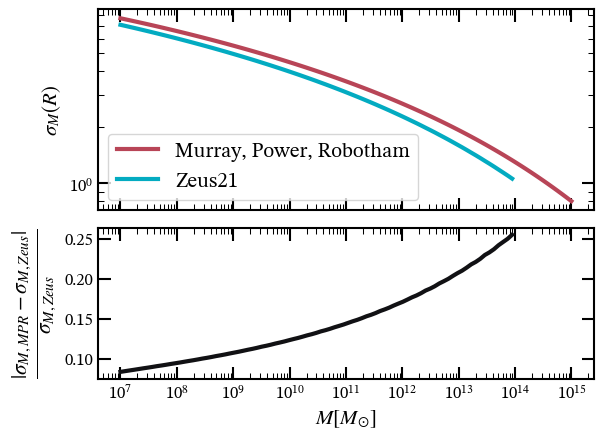

In [43]:
fig, ax = plt.subplots(2, 1, sharex = True, height_ratios = (2, 1.5))
plt.subplots_adjust(hspace = 0.1)
ax[0].plot(M_range, my_sigmam, label = r'Murray, Power, Robotham')
ax[0].plot(M_range, zeus_sigmam, label = r'Zeus21')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$\sigma_M(R)$')
ax[1].set_xlabel(r'$M [M_{\odot}]$')
ax[0].legend()
percent_diff_sigma = np.abs(my_sigmam - zeus_sigmam)/zeus_sigmam
ax[1].plot(M_range, percent_diff_sigma, color = '#111114')
ax[1].set_ylabel(r'$\frac{|\sigma_{M, MPR} - \sigma_{M, Zeus}|}{\sigma_{M, Zeus}}$', fontsize = 22)

#fig.savefig('/Users/eb35267/Desktop/research_code/figures/sigma_M_discrepancy.png', bbox_inches = 'tight')

# <span style='color:red'> Troubleshooting: calculate the HMF with $\sigma_M$ from Zeus21 <span>

In [44]:
def f_ST_test(M, delta_c, HMFintclass, A = 0.3222, a = 0.707, p = 0.3):
    sigma = HMFintclass.sigma_int(M, z=0)
    return A*np.sqrt(2*a/np.pi)*(1+(sigma**2/(a*delta_c**2)))**p*np.exp(-(delta_c**2/(2*sigma**2)))

In [45]:
def sigma_deriv_test(M_range, HMFintclass):
    sigma_M_range = HMFintclass.sigma_int(M_range, z=0.0)
    log_M = np.log(M_range)
    log_sigma = np.log(sigma_M_range)
    return np.abs(np.gradient(log_sigma, log_M))

In [46]:
def calc_hmf_test(M_range, HMFintclass, delta_c, rho_0):
    hmf = np.zeros_like(M_range)
    derivative = sigma_deriv_test(M_range, HMFintclass)
    for i, (M, deriv) in enumerate(zip(M_range, derivative)):
        f_M = f_ST_test(M, delta_c, HMFintclass)
        hmf[i] = CosmoParams.rho_M0/M*f_M*deriv
    return hmf

In [47]:
ST_test = calc_hmf_test(M_range, HMFintclass, delta_c, rho_0)
ST_test_bbk_units = ST_test * np.log(10)

/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_4197/4039298968.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hmf[i] = CosmoParams.rho_M0/M*f_M*deriv


In [48]:
percent_diff_hmf = np.abs(ST_test_bbk_units - hmf_st_bbk_units) / ST_test_bbk_units

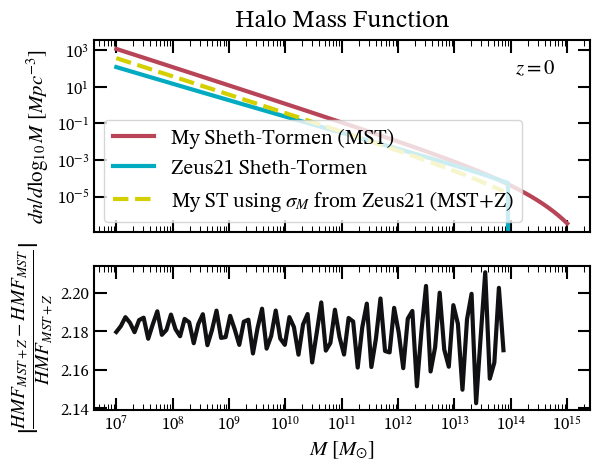

In [49]:
fig, ax = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': (2, 1.5)})
ax[0].plot(M_range, hmf_st_bbk_units, label='My Sheth-Tormen (MST)')
ax[0].plot(M_range, hmf_zeus_bbk_units, label='Zeus21 Sheth-Tormen')
ax[0].plot(M_range, ST_test_bbk_units, linestyle = '--', label=r'My ST using $\sigma_M$ from Zeus21 (MST+Z)')
ax[1].plot(M_range, percent_diff_hmf, color = '#111114')
ax[1].set_ylabel(r'$|\frac{HMF_{MST+Z} - HMF_{MST}}{HMF_{MST+Z}}|$', fontsize = 20)
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylabel(r'$dn/d\log_{10} M$ $[Mpc^{-3}]$')
ax[1].set_xlabel(r'$M$ $[M_{\odot}]$')
ax[0].set_title('Halo Mass Function')
ax[0].text(0.85, 0.8, r'$z=0$', transform=ax[0].transAxes, 
           verticalalignment='bottom', horizontalalignment='left')

ax[0].legend()

In [51]:
f_ST_test_val = f_ST_test(M_range, delta_c, HMFintclass, A = 0.3222, a = 0.707, p = 0.3)

In [52]:
f_ST_og_val = [f_ST(M, delta_c, rho_0, k_range) for M in M_range]

125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460.63733
12.576629446063732
125766294460

In [53]:
percent_diff_f = np.abs(f_ST_og_val - f_ST_test_val) / f_ST_test_val

Text(0, 0.5, '$\\frac{|f_Z(\\sigma) - f_{original}(\\sigma)|}{f_Z(\\sigma)}$')

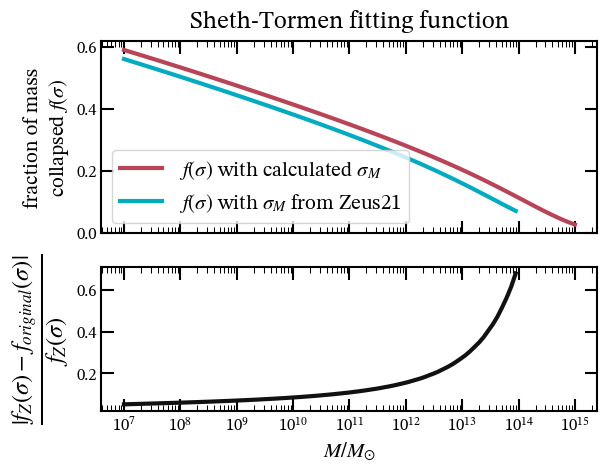

In [54]:
fig, ax = plt.subplots(2, 1, sharex = True, height_ratios = (2, 1.5))
ax[0].plot(M_range, f_ST_og_val, label = r'$f(\sigma)$ with calculated $\sigma_M$')
ax[0].plot(M_range, f_ST_test_val, label = r'$f(\sigma)$ with $\sigma_M$ from Zeus21')
ax[1].plot(M_range, percent_diff_f, color = '#111114')
ax[0].set_title('Sheth-Tormen fitting function')
ax[0].set_xscale('log')
ax[0].set_ylabel('fraction of mass\ncollapsed ' + r'$f(\sigma)$') # /n doesn't work in LaTeX rendering mode so I split it in two
ax[1].set_xlabel(r'$M / M_{\odot}$')
ax[0].legend()
ax[1].set_ylabel(r'$\frac{|f_Z(\sigma) - f_{original}(\sigma)|}{f_Z(\sigma)}$', fontsize = 25)

In [ ]:
sigma_deriv_og = sigma_deriv(M_range, rho_0, k_range)

In [ ]:
sigma_deriv_Zeus = sigma_deriv_test(M_range)

In [ ]:
percent_diff_sigma_deriv = np.abs(sigma_deriv_Zeus - sigma_deriv_og) / sigma_deriv_Zeus

In [ ]:
fig, ax = plt.subplots(2, 1, sharex = True, height_ratios = (2, 1.5))
ax[0].plot(M_range, sigma_deriv_og, label = r'calculated $\sigma_M$')
ax[0].plot(M_range, sigma_deriv_Zeus, label = r'$\sigma_M$ from Zeus21')
ax[1].plot(M_range, percent_diff_sigma_deriv, color = '#111114')
ax[0].set_xscale('log')
ax[0].set_ylabel(r'$|\frac{d\ln\sigma}{d\ln M}|$', fontsize = 25) 
ax[1].set_xlabel(r'$M / M_{\odot}$')
ax[0].legend()
ax[1].set_ylabel(r'% diff')

In [ ]:
fig, ax = plt.subplots(2, 1, sharex = True, height_ratios = (2, 1.5))
ax[0].plot(M_range, combined_og, label = r'calculated $\sigma_M$')
ax[0].plot(M_range, combined_Zeus, label = r'$\sigma_M$ from Zeus21')
ax[1].plot(M_range, combined_percent_diff, color = '#111114')
ax[0].set_xscale('log')
ax[0].set_ylabel(r'$f(\sigma) \cdot |\frac{d\ln\sigma}{d\ln M}|$', fontsize = 25) 
ax[1].set_xlabel(r'$M / M_{\odot}$')
ax[0].legend()
ax[1].set_ylabel(r'% diff')